# LSTM Model

## Objective

This notebook develops a Long Short-Term Memory (LSTM) neural network for forecasting hourly German electricity demand.

The data are scaled and transformed into sequential observations suitable for deep learning. Model performance is evaluated using RMSE, MAE and MAPE and compared with the benchmark, SARIMA, SARIMAX and feature-based forecasting models.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

## Load Dataset

The hourly electricity demand dataset is loaded and prepared for LSTM modelling.

In [2]:
# Load hourly electricity demand data

hourly_load = pd.read_csv(
    "/content/hourly_load.csv",
    index_col="timestamp",
    parse_dates=True
)

hourly_load.head()

,load
timestamp,
2015-01-01 00:00:00+00:00,41151.0
2015-01-01 01:00:00+00:00,40135.0
2015-01-01 02:00:00+00:00,39106.0
2015-01-01 03:00:00+00:00,38765.0
2015-01-01 04:00:00+00:00,38941.0


## Forecast Evaluation Function

A reusable evaluation function is defined to calculate RMSE, MAE and MAPE for evaluating forecast accuracy.

In [3]:
def evaluate_forecast(actual, forecast):

    rmse = np.sqrt(mean_squared_error(actual, forecast))
    mae = mean_absolute_error(actual, forecast)
    mape = np.mean(np.abs((actual - forecast) / actual)) * 100

    return {
        "RMSE": rmse,
        "MAE": mae,
        "MAPE": mape
    }

## Train-Test Split

The hourly electricity demand data are divided into training and testing sets. The final two years (17,520 hourly observations) are reserved as the test set to evaluate the forecasting performance of the LSTM model.

In [4]:
# Reserve the last two years of hourly data for testing

forecast_horizon = 24 * 365 * 2   # 17,520 hours

train = hourly_load.iloc[:-forecast_horizon]

test = hourly_load.iloc[-forecast_horizon:]

print("Training observations:", len(train))
print("Testing observations:", len(test))

Training observations: 32880
Testing observations: 17520


## Data Preprocessing

The hourly electricity demand data are scaled using Min-Max normalisation before training the LSTM network. Scaling improves numerical stability and helps the neural network converge more efficiently.

## Data Scaling

The electricity demand values are scaled to the range [0,1] using Min-Max scaling to improve neural network training stability.

In [5]:
scaler = MinMaxScaler()

train_scaled = scaler.fit_transform(train[["load"]])

test_scaled = scaler.transform(test[["load"]])

## Sequence Preparation

Sliding window sequences are created from the scaled hourly electricity demand series. Each sequence contains previous observations used by the LSTM model to predict the next value.

## Sequence Generation

Input sequences are created from the scaled time series to enable the LSTM model to learn temporal dependencies.

In [6]:
# Number of previous hourly observations used for prediction

look_back = 24


def create_sequences(data, look_back):

    X, y = [], []

    for i in range(len(data) - look_back):
        X.append(data[i:i + look_back])
        y.append(data[i + look_back])

    return np.array(X), np.array(y)


# Create training sequences

X_train, y_train = create_sequences(
    train_scaled,
    look_back
)

# Create testing sequences

combined = np.concatenate(
    [train_scaled[-look_back:], test_scaled]
)

X_test, y_test = create_sequences(
    combined,
    look_back
)

# Reshape for LSTM input

X_train = X_train.reshape(
    X_train.shape[0],
    X_train.shape[1],
    1
)

X_test = X_test.reshape(
    X_test.shape[0],
    X_test.shape[1],
    1
)

print("Training sequences:", X_train.shape)
print("Testing sequences:", X_test.shape)

Training sequences: (32856, 24, 1)
Testing sequences: (17520, 24, 1)


## LSTM Model Architecture

A Long Short-Term Memory (LSTM) neural network is used to model hourly electricity demand. The model consists of a single LSTM layer with 64 hidden units followed by a dense output layer that predicts the next hourly electricity demand value. The model is trained using the Adam optimizer with Mean Squared Error (MSE) as the loss function.

In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense

# Build LSTM model

model = Sequential([

    Input(shape=(look_back, 1)),

    LSTM(
        64,
        activation="tanh"
    ),

    Dense(1)

])

model.compile(
    optimizer="adam",
    loss="mse"
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,961 (66.25 KB)

 Trainable params: 16,961 (66.25 KB)

 Non-trainable params: 0 (0.00 B)

## Model Training

The LSTM model is trained using the training sequences for 100 epochs with a batch size of 16. A validation split of 10% is used to monitor model performance during training and assess convergence.

In [8]:
# Train the LSTM model

history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.1,
    verbose=1
)

Epoch 1/100
1849/1849 ━━━━━━━━━━━━━━━━━━━━ 23s 11ms/step - loss: 0.0057 - val_loss: 0.0010
Epoch 2/100
1849/1849 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - loss: 0.0010 - val_loss: 6.6493e-04
Epoch 3/100
1849/1849 ━━━━━━━━━━━━━━━━━━━━ 22s 12ms/step - loss: 8.1133e-04 - val_loss: 6.4737e-04
Epoch 4/100
1849/1849 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - loss: 7.2229e-04 - val_loss: 4.6221e-04
Epoch 5/100
1849/1849 ━━━━━━━━━━━━━━━━━━━━ 22s 12ms/step - loss: 5.9041e-04 - val_loss: 3.7052e-04
Epoch 6/100
1849/1849 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - loss: 4.8500e-04 - val_loss: 3.4031e-04
Epoch 7/100
1849/1849 ━━━━━━━━━━━━━━━━━━━━ 22s 12ms/step - loss: 4.3360e-04 - val_loss: 3.1661e-04
Epoch 8/100
1849/1849 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - loss: 4.0140e-04 - val_loss: 2.5438e-04
Epoch 9/100
1849/1849 ━━━━━━━━━━━━━━━━━━━━ 42s 12ms/step - loss: 3.6611e-04 - val_loss: 2.6589e-04
Epoch 10/100
1849/1849 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - loss: 3.4972e-04 - val_loss: 2.4647e-04
Epoch 11/100
1849/184

## Training Loss

The training and validation loss curves are plotted to evaluate the learning behaviour of the LSTM model during training.

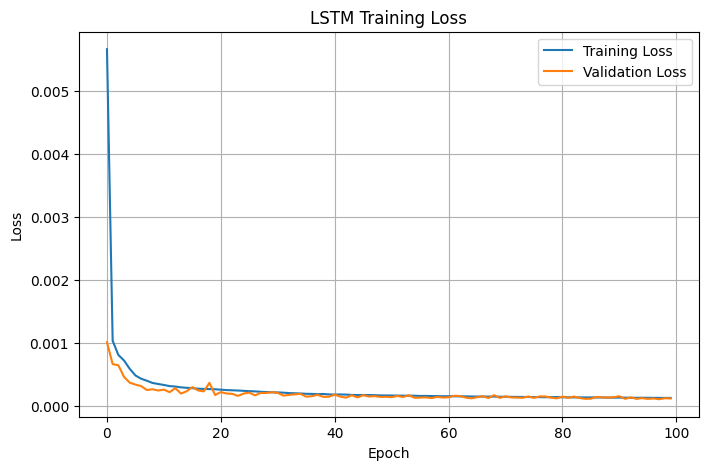

In [9]:
# Plot training history

plt.figure(figsize=(8,5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("LSTM Training Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.savefig(
    "lstm_training_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Forecast Generation

The trained LSTM model is used to predict hourly electricity demand for the test period. Since the model was trained on scaled data, both the forecasts and actual observations are transformed back to the original electricity demand scale before evaluation.

In [10]:
# Generate hourly forecasts

predictions = model.predict(X_test)

# Convert predictions back to original scale

predictions = scaler.inverse_transform(predictions)

# Convert actual values back to original scale

y_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

548/548 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step


## Forecast Visualisation

The forecasted hourly electricity demand is compared with the observed values over the test period to assess prediction accuracy.

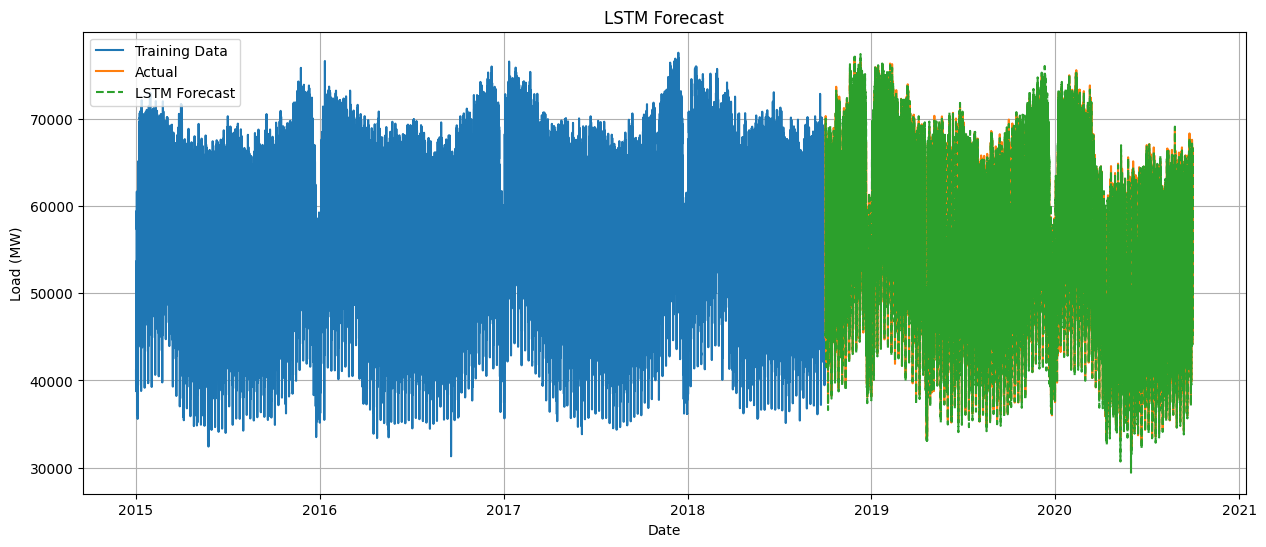

In [12]:
# Plot forecasts

plt.figure(figsize=(15,6))

plt.plot(
    train.index,
    train["load"],
    label="Training Data"
)

plt.plot(
    test.index,
    test["load"],
    label="Actual"
)

plt.plot(
    test.index,
    predictions.flatten(),
    linestyle="--",
    label="LSTM Forecast"
)

plt.title("LSTM Forecast")

plt.xlabel("Date")

plt.ylabel("Load (MW)")

plt.legend()

plt.grid(True)

plt.savefig(
    "lstm_forecast.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Forecast Evaluation

The forecasting accuracy of the LSTM model is assessed using RMSE, MAE and MAPE.

In [13]:
# Calculate evaluation metrics

lstm_metrics = evaluate_forecast(
    y_actual.flatten(),
    predictions.flatten()
)

print(lstm_metrics)

{'RMSE': np.float64(643.1807917189451), 'MAE': 490.1069266820063, 'MAPE': np.float64(0.9117866759805854)}


In [14]:
# Save evaluation metrics

lstm_metrics_df = pd.DataFrame([lstm_metrics])

lstm_metrics_df.to_csv(
    "lstm_metrics.csv",
    index=False
)

lstm_metrics_df

,RMSE,MAE,MAPE
0,643.180792,490.106927,0.911787


In [15]:
# Save LSTM forecasts

forecast_df = pd.DataFrame({
    "Actual": y_actual.flatten(),
    "Forecast": predictions.flatten()
}, index=test.index)

forecast_df.to_csv("lstm_forecast.csv")

forecast_df.head()

,Actual,Forecast
timestamp,,
2018-10-02 00:00:00+00:00,44899.0,45695.589844
2018-10-02 01:00:00+00:00,45550.0,45111.171875
2018-10-02 02:00:00+00:00,47150.0,47055.050781
2018-10-02 03:00:00+00:00,51794.0,51308.316406
2018-10-02 04:00:00+00:00,59531.0,61377.230469
